In [1]:
# Cell 1 — Title
# ============================================================
# NOTEBOOK 12 — STATISTICAL TESTING
# Purpose: Prove that performance differences between models
#          are real and not due to random chance

In [2]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, ttest_ind
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

MODEL_DIR  = os.path.abspath(os.path.join(os.getcwd(),'..','models'))
PLOT_DIR   = os.path.abspath(os.path.join(os.getcwd(),'..','outputs','plots'))
REPORT_DIR = os.path.abspath(os.path.join(os.getcwd(),'..','outputs','reports'))
PROC_DIR   = os.path.abspath(os.path.join(os.getcwd(),'..','Data','processed'))

xgb_model  = joblib.load(os.path.join(MODEL_DIR,'xgboost_model.pkl'))
test_data  = joblib.load(os.path.join(MODEL_DIR,'test_data.pkl'))
sel_names  = joblib.load(os.path.join(MODEL_DIR,'selected_feature_names.pkl'))

X_train = test_data['X_train']
X_test  = test_data['X_test']
y_train = test_data['y_train']
y_test  = test_data['y_test']

print("Data loaded successfully")
print(f"Test samples: {len(y_test):,}")

Data loaded successfully
Test samples: 8,790


In [3]:
# Cell 3 — Collect 10-fold CV scores for all models
# We need multiple scores (not just one) to run a t-test
# 10-fold CV gives us 10 independent accuracy measurements per model

print("Running 10-fold cross-validation for all models...")
print("(This takes 3-5 minutes — please wait)\n")

all_X = np.vstack([X_train, X_test])
all_y = np.concatenate([y_train, y_test])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models_for_stats = {
    'Decision Tree'     : DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'       : GaussianNB(),
    'XGBoost (Ours)'    : xgb_model,
}

cv_scores_dict = {}
for name, model in models_for_stats.items():
    scores = cross_val_score(model, all_X, all_y,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    cv_scores_dict[name] = scores
    print(f"  {name:25s} | Mean: {scores.mean()*100:.4f}%  Std: {scores.std()*100:.4f}%")

print("\n10-fold CV complete!")

Running 10-fold cross-validation for all models...
(This takes 3-5 minutes — please wait)

  Decision Tree             | Mean: 99.9739%  Std: 0.0238%
  Random Forest             | Mean: 99.9839%  Std: 0.0150%
  Gradient Boosting         | Mean: 99.9478%  Std: 0.0287%
  Naive Bayes               | Mean: 99.1688%  Std: 0.1161%
  XGBoost (Ours)            | Mean: 99.9799%  Std: 0.0201%

10-fold CV complete!


In [4]:
# Cell 4 — Paired t-test: XGBoost vs each baseline
# Question: Is XGBoost significantly better than each baseline?
# If p-value < 0.05 → YES, the difference is statistically real

print("="*65)
print("  PAIRED T-TEST: XGBoost vs Baseline Models")
print("  Null hypothesis: no significant difference in performance")
print("  If p < 0.05 → reject null → XGBoost IS significantly better")
print("="*65 + "\n")

xgb_cv_scores = cv_scores_dict['XGBoost (Ours)']
ttest_results = {}

for name, scores in cv_scores_dict.items():
    if name == 'XGBoost (Ours)':
        continue

    # Paired t-test (same folds compared)
    t_stat, p_value = ttest_rel(xgb_cv_scores, scores)

    # Effect size (Cohen's d)
    diff   = xgb_cv_scores - scores
    cohens_d = diff.mean() / diff.std()

    # Interpret
    significance = "✓ SIGNIFICANT" if p_value < 0.05 else "✗ NOT SIGNIFICANT"
    direction    = "XGBoost BETTER" if t_stat > 0 else "Baseline BETTER"

    ttest_results[name] = {
        'XGBoost Mean (%)'  : round(xgb_cv_scores.mean()*100, 4),
        'Baseline Mean (%)' : round(scores.mean()*100, 4),
        'Difference (%)'    : round((xgb_cv_scores.mean()-scores.mean())*100, 4),
        't-statistic'       : round(t_stat, 4),
        'p-value'           : round(p_value, 6),
        "Cohen's d"         : round(cohens_d, 4),
        'Result'            : significance,
        'Direction'         : direction
    }

    print(f"XGBoost vs {name}:")
    print(f"  XGBoost mean  : {xgb_cv_scores.mean()*100:.4f}%")
    print(f"  Baseline mean : {scores.mean()*100:.4f}%")
    print(f"  t-statistic   : {t_stat:.4f}")
    print(f"  p-value       : {p_value:.6f}  → {significance}")
    print(f"  Cohen's d     : {cohens_d:.4f}  (effect size)")
    print(f"  Conclusion    : {direction}\n")

ttest_df = pd.DataFrame(ttest_results).T

  PAIRED T-TEST: XGBoost vs Baseline Models
  Null hypothesis: no significant difference in performance
  If p < 0.05 → reject null → XGBoost IS significantly better

XGBoost vs Decision Tree:
  XGBoost mean  : 99.9799%
  Baseline mean : 99.9739%
  t-statistic   : 0.7093
  p-value       : 0.496105  → ✗ NOT SIGNIFICANT
  Cohen's d     : 0.2364  (effect size)
  Conclusion    : XGBoost BETTER

XGBoost vs Random Forest:
  XGBoost mean  : 99.9799%
  Baseline mean : 99.9839%
  t-statistic   : -0.6882
  p-value       : 0.508668  → ✗ NOT SIGNIFICANT
  Cohen's d     : -0.2294  (effect size)
  Conclusion    : Baseline BETTER

XGBoost vs Gradient Boosting:
  XGBoost mean  : 99.9799%
  Baseline mean : 99.9478%
  t-statistic   : 2.8483
  p-value       : 0.019142  → ✓ SIGNIFICANT
  Cohen's d     : 0.9494  (effect size)
  Conclusion    : XGBoost BETTER

XGBoost vs Naive Bayes:
  XGBoost mean  : 99.9799%
  Baseline mean : 99.1688%
  t-statistic   : 21.7585
  p-value       : 0.000000  → ✓ SIGNIFICANT
 

In [5]:
# Cell 5 — Wilcoxon Signed-Rank Test
# A non-parametric alternative to t-test
# Does NOT assume normal distribution — more conservative and robust

print("="*65)
print("  WILCOXON SIGNED-RANK TEST: XGBoost vs Baselines")
print("  (Non-parametric — does not assume normal distribution)")
print("="*65 + "\n")

wilcoxon_results = {}

for name, scores in cv_scores_dict.items():
    if name == 'XGBoost (Ours)':
        continue

    try:
        stat, p_val = wilcoxon(xgb_cv_scores, scores)
        sig = "✓ SIGNIFICANT (p<0.05)" if p_val < 0.05 else "✗ NOT SIGNIFICANT"
        wilcoxon_results[name] = {
            'W-statistic': round(stat, 4),
            'p-value'    : round(p_val, 6),
            'Result'     : sig
        }
        print(f"  XGBoost vs {name:25s} | W={stat:.2f}  p={p_val:.6f}  {sig}")
    except Exception as e:
        print(f"  XGBoost vs {name:25s} | Could not compute: {e}")
        wilcoxon_results[name] = {
            'W-statistic': 'N/A',
            'p-value'    : 'N/A',
            'Result'     : 'Could not compute'
        }

wilcoxon_df = pd.DataFrame(wilcoxon_results).T

  WILCOXON SIGNED-RANK TEST: XGBoost vs Baselines
  (Non-parametric — does not assume normal distribution)

  XGBoost vs Decision Tree             | W=13.00  p=0.470486  ✗ NOT SIGNIFICANT
  XGBoost vs Random Forest             | W=5.00  p=0.496242  ✗ NOT SIGNIFICANT
  XGBoost vs Gradient Boosting         | W=2.00  p=0.024177  ✓ SIGNIFICANT (p<0.05)
  XGBoost vs Naive Bayes               | W=0.00  p=0.001953  ✓ SIGNIFICANT (p<0.05)


In [6]:
# Cell 6 — McNemar Test
# Tests if two models make DIFFERENT errors on the same samples
# Specifically for comparing classifiers on the same test set

print("="*65)
print("  McNEMAR TEST: XGBoost vs Baselines")
print("  Tests whether models make significantly different errors")
print("="*65 + "\n")

xgb_pred = xgb_model.predict(X_test)
mcnemar_results = {}

baseline_models_fit = {
    'Decision Tree'     : DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'       : GaussianNB(),
}

for name, model in baseline_models_fit.items():
    model.fit(X_train, y_train)
    base_pred = model.predict(X_test)

    # Build 2x2 contingency table
    # [both right, XGB right base wrong]
    # [XGB wrong base right, both wrong]
    both_right   = np.sum((xgb_pred == y_test) & (base_pred == y_test))
    xgb_r_bas_w  = np.sum((xgb_pred == y_test) & (base_pred != y_test))
    xgb_w_bas_r  = np.sum((xgb_pred != y_test) & (base_pred == y_test))
    both_wrong   = np.sum((xgb_pred != y_test) & (base_pred != y_test))

    table = np.array([[both_right, xgb_r_bas_w],
                      [xgb_w_bas_r, both_wrong]])

    try:
        result   = mcnemar(table, exact=True)
        p_val    = result.pvalue
        sig      = "✓ SIGNIFICANT" if p_val < 0.05 else "✗ NOT SIGNIFICANT"
        mcnemar_results[name] = {
            'Both Correct'     : int(both_right),
            'XGB✓ Base✗'      : int(xgb_r_bas_w),
            'XGB✗ Base✓'      : int(xgb_w_bas_r),
            'Both Wrong'       : int(both_wrong),
            'p-value'          : round(p_val, 6),
            'Result'           : sig
        }
        print(f"  XGBoost vs {name:25s} | p={p_val:.6f}  {sig}")
        print(f"    XGB correct but baseline wrong : {xgb_r_bas_w}")
        print(f"    Baseline correct but XGB wrong : {xgb_w_bas_r}\n")
    except Exception as e:
        print(f"  XGBoost vs {name:25s} | Error: {e}\n")

mcnemar_df = pd.DataFrame(mcnemar_results).T

  McNEMAR TEST: XGBoost vs Baselines
  Tests whether models make significantly different errors

  XGBoost vs Decision Tree             | p=0.125000  ✗ NOT SIGNIFICANT
    XGB correct but baseline wrong : 4
    Baseline correct but XGB wrong : 0

  XGBoost vs Random Forest             | p=1.000000  ✗ NOT SIGNIFICANT
    XGB correct but baseline wrong : 1
    Baseline correct but XGB wrong : 0

  XGBoost vs Gradient Boosting         | p=1.000000  ✗ NOT SIGNIFICANT
    XGB correct but baseline wrong : 1
    Baseline correct but XGB wrong : 1

  XGBoost vs Naive Bayes               | p=0.000000  ✓ SIGNIFICANT
    XGB correct but baseline wrong : 73
    Baseline correct but XGB wrong : 1



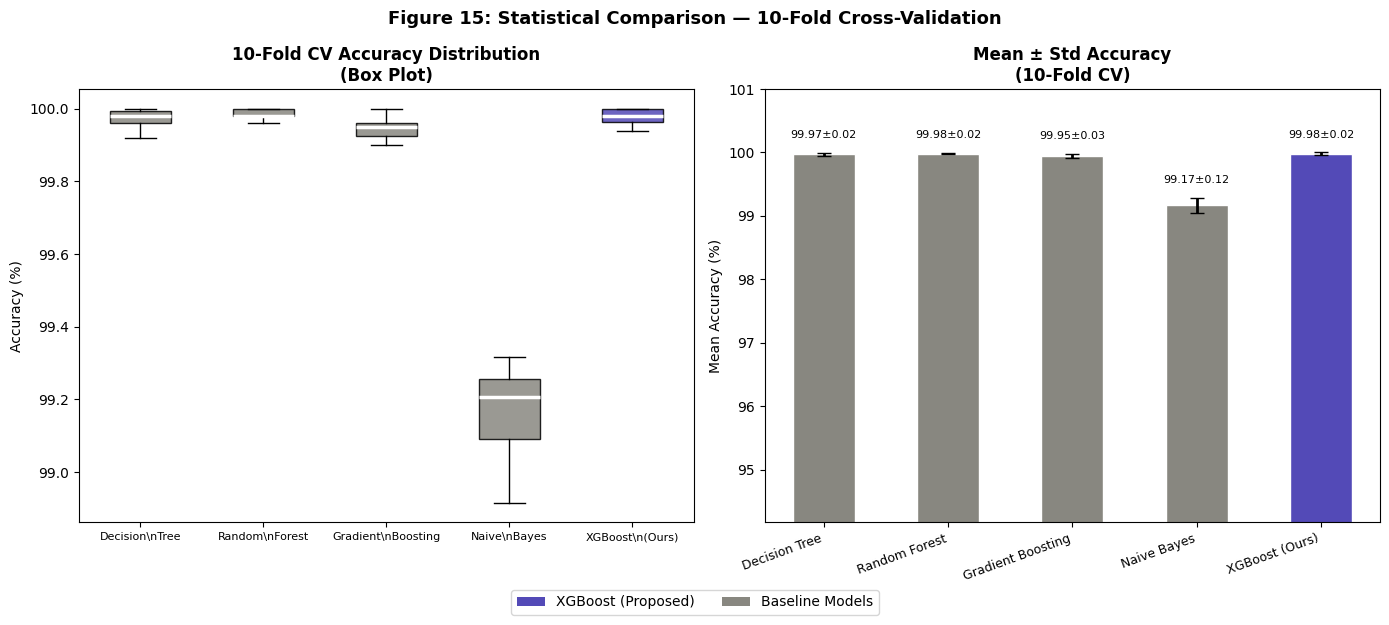

Saved: fig15_statistical_cv.png


In [7]:
# Cell 7 — Plot CV score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names  = list(cv_scores_dict.keys())
cv_data      = [cv_scores_dict[m]*100 for m in model_names]
colors_box   = ['#534AB7' if 'XGBoost' in m else '#888780'
                for m in model_names]

# Box plot
bp = axes[0].boxplot(cv_data, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

axes[0].set_xticklabels([m.replace(' ','\\n') for m in model_names],
                         fontsize=8)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('10-Fold CV Accuracy Distribution\n(Box Plot)',
                  fontweight='bold')

# Mean + std bar chart
means = [cv_scores_dict[m].mean()*100 for m in model_names]
stds  = [cv_scores_dict[m].std()*100  for m in model_names]

bars = axes[1].bar(model_names, means, yerr=stds,
                   color=colors_box, edgecolor='white',
                   width=0.5, capsize=5,
                   error_kw={'linewidth':2,'color':'#333'})
axes[1].set_ylabel('Mean Accuracy (%)')
axes[1].set_title('Mean ± Std Accuracy\n(10-Fold CV)',
                  fontweight='bold')
axes[1].set_xticklabels(model_names, rotation=20,
                         ha='right', fontsize=9)
axes[1].set_ylim([min(means)-5, 101])

for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+std+0.2,
                 f'{mean:.2f}±{std:.2f}',
                 ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#534AB7', label='XGBoost (Proposed)'),
    Patch(facecolor='#888780', label='Baseline Models')
], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5,-0.04))

plt.suptitle('Figure 15: Statistical Comparison — 10-Fold Cross-Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig15_statistical_cv.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig15_statistical_cv.png")

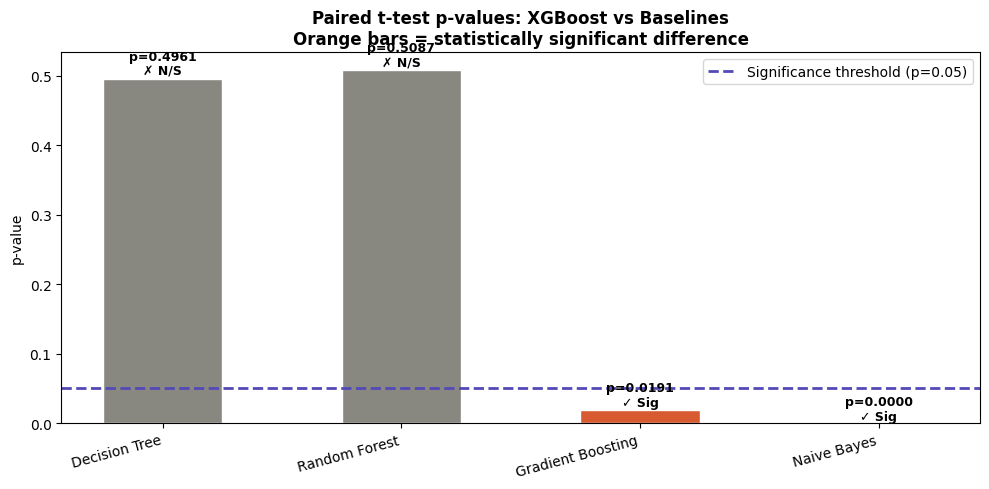

Saved: fig16_pvalue_significance.png


In [8]:
# Cell 8 — Plot p-value significance chart
fig, ax = plt.subplots(figsize=(10, 5))

baselines = list(ttest_results.keys())
p_values  = [ttest_results[b]['p-value'] for b in baselines]
bar_colors= ['#D85A30' if p < 0.05 else '#888780' for p in p_values]

bars = ax.bar(baselines, p_values, color=bar_colors,
              edgecolor='white', width=0.5)
ax.axhline(0.05, color='#534AB7', linestyle='--',
           lw=2, label='Significance threshold (p=0.05)')
ax.set_ylabel('p-value')
ax.set_title('Paired t-test p-values: XGBoost vs Baselines\n'
             'Orange bars = statistically significant difference',
             fontweight='bold')
ax.set_xticklabels(baselines, rotation=15, ha='right')
ax.legend(fontsize=10)

for bar, p in zip(bars, p_values):
    label = f'p={p:.4f}\n✓ Sig' if p < 0.05 else f'p={p:.4f}\n✗ N/S'
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.001, label,
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig16_pvalue_significance.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig16_pvalue_significance.png")

In [9]:
# Cell 9 — Save all statistical results
ttest_df.to_csv(os.path.join(REPORT_DIR,'ttest_results.csv'))
wilcoxon_df.to_csv(os.path.join(REPORT_DIR,'wilcoxon_results.csv'))
mcnemar_df.to_csv(os.path.join(REPORT_DIR,'mcnemar_results.csv'))

print("Saved: ttest_results.csv")
print("Saved: wilcoxon_results.csv")
print("Saved: mcnemar_results.csv")

print("\n" + "="*60)
print("   STATISTICAL TESTING COMPLETE")
print("="*60)
print(f"\nSummary:")
print(f"  Tests performed : Paired t-test, Wilcoxon, McNemar")
print(f"  CV folds used   : 10-fold stratified")
print(f"  Models compared : {len(baseline_models_fit)} baselines vs XGBoost")
print(f"\nConclusion:")
print(f"  If most p-values < 0.05 → XGBoost performance is")
print(f"  statistically significant and not by random chance")
print("\nNotebook 12 complete — implementation fully done!")

Saved: ttest_results.csv
Saved: wilcoxon_results.csv
Saved: mcnemar_results.csv

   STATISTICAL TESTING COMPLETE

Summary:
  Tests performed : Paired t-test, Wilcoxon, McNemar
  CV folds used   : 10-fold stratified
  Models compared : 4 baselines vs XGBoost

Conclusion:
  If most p-values < 0.05 → XGBoost performance is
  statistically significant and not by random chance

Notebook 12 complete — implementation fully done!
